# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [19]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

from NOP import *

import matplotlib.pyplot as plt
from shapely import wkt


# Configuration

# Query the surveys

In [21]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
#report_bc.to_csv('Reports_used.csv', mode='a', header=False, index=False)
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
# Create a GeoDataFrame for the segments with geometry from the Breadcrumb column
segments['geometry'] = segments['Breadcrumb'].apply(wkt.loads)
segments_gdf = gpd.GeoDataFrame(segments, geometry='geometry', crs='EPSG:4326')


In [22]:
# Get the unique SurveyIds from the segments DataFrame
survey_ids = pd.DataFrame(segments['SurveyId'].unique(), columns=['SurveyId'])
survey_ids.db.set_query(f"SELECT SA.SurveyId, Shape.STAsText() as SurveyAreaBoundary FROM SurveyArea SA WHERE SA.SurveyId IN (SELECT SurveyId FROM #TempSurveys)")
s = survey_ids.db.execute(EU2_Conn, source_col = 'SurveyId', temp_table_name = '#TempSurveys')

In [23]:
s['geometry'] = s['SurveyAreaBoundary'].apply(wkt.loads)
s_gdf = gpd.GeoDataFrame(s, geometry='geometry', crs='EPSG:4326')

In [24]:
# Get the segments for each survey (as a list of DataFrames)
segments_per_survey = [df for _, df in segments.groupby('SurveyId')]
output = []
surveys = []

survey_gdf = segments_per_survey[1].copy()
survey_gdf['geometry'] = survey_gdf['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey_gdf, geometry='geometry', crs='EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)
survey_gdf.set_geometry('geometry', inplace=True)
surveys.append(survey_gdf)
survey_gdf.nop.prepare_survey_gdf()
cell = survey_gdf.nop.generate_grid()
net = survey_gdf.nop.create_network()


Center of the bounds: POINT (656870.99477 5939079.056679999)
Processing angle:  0
Processing angle:  -10.0
Processing angle:  -20.0
Processing angle:  -30.0
Processing angle:  -40.0
Processing angle:  -50.0
Processing angle:  -60.0
Processing angle:  -70.0
Processing angle:  -80.0
Processing angle:  -90.0
Processing angle:  -100.0
Processing angle:  -110.0
Processing angle:  -120.0
Processing angle:  -130.0
Processing angle:  -140.0
Processing angle:  -150.0
Processing angle:  -160.0
Processing angle:  -170.0
Processing angle:  -180.0
Total boundaries: 3939
Boundaries with no NaN 'nop': 3886
Boundaries after length and spread filters: 3361
Boundaries after removing overlaps: 2505
Boundaries after removing close together cells: 2404
2404 splitters -> 2351 cells
Created network with 2351 nodes and 2397 edges.


In [48]:
cell = survey_gdf.nop.count_nop()

In [49]:
# Convert 'cell' GeoDataFrame to EPSG:4326
cell_4326 = cell.to_crs(4326)
# Get the bounding box of the cell_4326 GeoDataFrame
bounds = cell_4326.total_bounds  # returns [minx, miny, maxx, maxy]
print(f"Bounding box: {bounds}")

import osmnx as ox

# osmnx >= 2.0: graph_from_bbox takes a single bbox tuple (left, bottom, right, top)
#               i.e., (west, south, east, north) in EPSG:4326
# To download *everything*, use network_type="all". Note that "all_private" is not valid for newer OSMnx versions.
# If you want both drivable and non-drivable (e.g. service, footway, parking lot, paths), use "all".
G = ox.graph_from_bbox(bounds, network_type="all")

# Convert to GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.set_crs("EPSG:4326", allow_override=True)
edges.to_crs(cell.crs, inplace=True)

Bounding box: [-0.65462448 53.56428516 -0.6071483  53.58947428]


<Axes: >

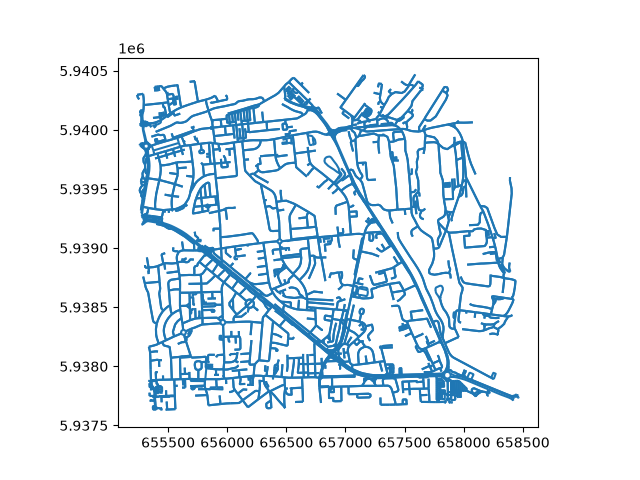

In [50]:
edges.plot()

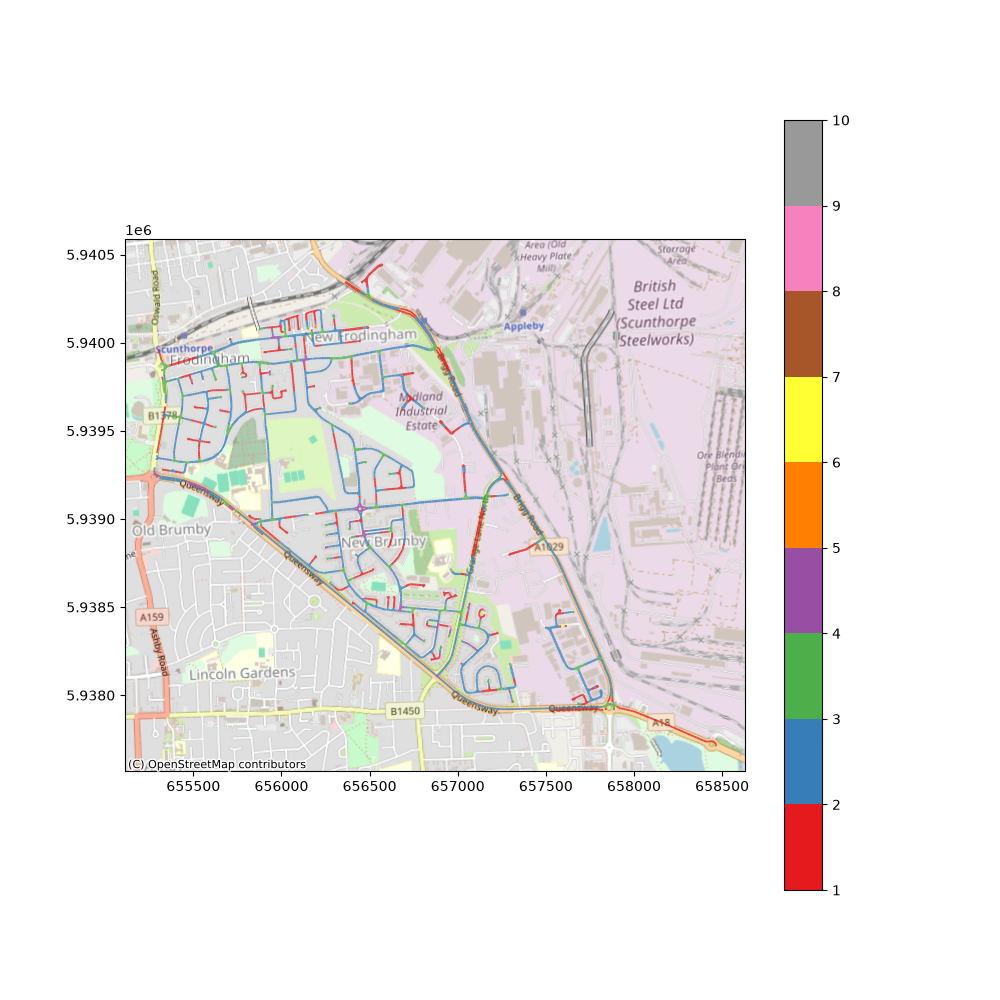

<Axes: >

In [53]:
import matplotlib.pyplot as plt
import contextily as ctx

ax = cell.plot(column='n_passes', cmap='Set1', legend=True, figsize=(10, 10), alpha=0.8)
ctx.add_basemap(ax, crs=cell.crs, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()
edges.plot(ax = ax, color = 'black')
survey_gdf.plot(ax = ax, color = 'yellow')